### Basis of the Automation of Hydroelectric Turbines

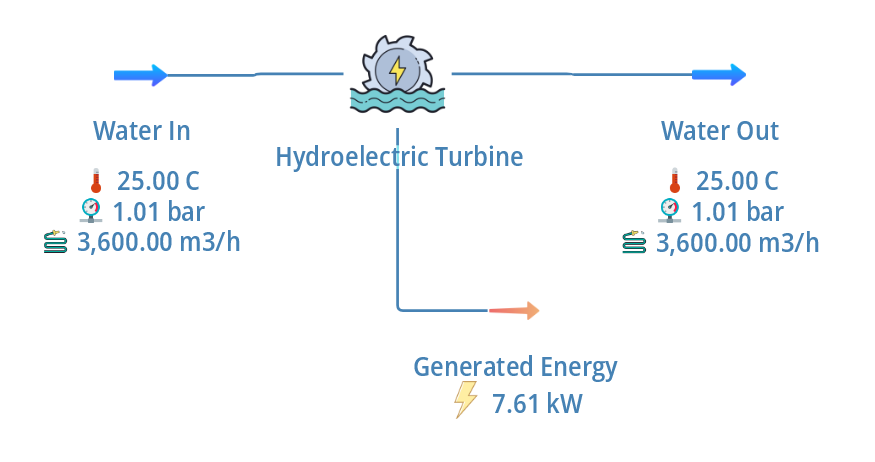

In [1]:
# Import the display function from the IPython.display module
from IPython.display import display

# Import the Image class from the PIL module
from PIL import Image

# Open an image file using the Image class and assign it to the variable Basis_image
Basis_image = Image.open("/workspace/05 Automation of Hydroelectric Turbines/05 Automation of Hydroelectric Turbines.png")

# Display the Basis_image using the display function from IPython.display
display(Basis_image)

In [2]:
import os
os.environ["PYTHONNET_RUNTIME"] = "coreclr"
os.environ["DOTNET_SYSTEM_DRAWING_USE_GDIPLUS"] = "1"

import clr
import numpy as np
import time
from datetime import timedelta
from pythonnet import load
from System import Environment, Array, String

# Load .NET Core runtime
load("coreclr")

# Try to import System.IO; fallback to os.chdir if it fails
try:
    from System.IO import Directory, Path, File
    use_dotnet_dir = True
except Exception as e:
    print(f"Note: System.IO import failed ({e}), using os.chdir instead")
    import os
    use_dotnet_dir = False

# Define DWSIM path
dwsimpath = "/usr/local/lib/dwsim/"

# Set working directory
if use_dotnet_dir:
    Directory.SetCurrentDirectory(dwsimpath)
else:
    os.chdir(dwsimpath)

# Add DWSIM assemblies
clr.AddReference(dwsimpath + "CapeOpen.dll")
clr.AddReference(dwsimpath + "DWSIM.Automation.dll")
clr.AddReference(dwsimpath + "DWSIM.Interfaces.dll")
clr.AddReference(dwsimpath + "DWSIM.GlobalSettings.dll")
clr.AddReference(dwsimpath + "DWSIM.SharedClasses.dll")
clr.AddReference(dwsimpath + "DWSIM.Thermodynamics.dll")
clr.AddReference(dwsimpath + "DWSIM.UnitOperations.dll")
clr.AddReference(dwsimpath + "DWSIM.Inspector.dll")
clr.AddReference(dwsimpath + "System.Buffers.dll")
clr.AddReference(dwsimpath + "DWSIM.Thermodynamics.ThermoC.dll")

# Now import DWSIM types
from DWSIM.Interfaces.Enums.GraphicObjects import ObjectType
from DWSIM.Thermodynamics import Streams, PropertyPackages
from DWSIM.UnitOperations import UnitOperations
from DWSIM.Automation import Automation3
from DWSIM.GlobalSettings import Settings

print("DWSIM imports successful!")

DWSIM imports successful!


In [3]:
# Create an instance of the Automation3 class from the DWSIM.Automation module
# This class provides methods for automating tasks in DWSIM, such as creating and manipulating flowsheets
interf = Automation3()

In [4]:
# Set the file path of an existing DWSIM flowsheet to be loaded using the Path.Combine method from the System.IO module
# The flowsheet file path is constructed using the Environment.GetFolderPath method to obtain the path to the desktop folder and the relative path to the flowsheet file
fileNameToLoad = Path.Combine(Environment.GetFolderPath(Environment.SpecialFolder.Desktop), "/workspace/05 Automation of Hydroelectric Turbines/05 Automation of Hydroelectric Turbines.dwxmz")

# Load the DWSIM flowsheet using the LoadFlowsheet method of the Automation3 class
# The method takes a single argument, which is the file path of the flowsheet to be loaded
# The method returns a Simulation object that represents the loaded flowsheet
sim = interf.LoadFlowsheet(fileNameToLoad)

### Calling Hydroelectric Turbine as a object

In [5]:
HT = sim.GetObject("Hydroelectric Turbine")
HT = HT.GetAsObject()

### Getting the calculation parameters

In [6]:
print(HT.get_Efficiency())
print(HT.get_StaticHead())
print(HT.get_InletVelocity())
print(HT.get_OutletVelocity())

75.0
1.0
1.0
0.5


### Getting the Results

In [7]:
print(HT.get_VelocityHead())
print(HT.get_TotalHead())
print(HT.get_GeneratedPower())

0.038265306122449
1.03826530612245
7.60872279398433


### Automation of Hydroelectric Turbines for a range of static head

In [8]:
from tabulate import tabulate

# Set the initial static head
Static_head = float(input("Enter the initial static head: "))

# Set the solver mode to use the default solver
Settings.SolverMode = 0

# Create an empty list to store the results
results = []

# Iterate 10 times, increasing the static head by 1 m each time
for i in range(10):
    # Set the new static head
    HT.set_StaticHead(Static_head)
    
    # Calculate the flowsheet
    errors = interf.CalculateFlowsheet2(sim)
    
    # Get the results
    Velocity_head = HT.get_VelocityHead()
    Total_Head = HT.get_TotalHead()
    Power = HT.get_GeneratedPower()

    # Append the results to the list
    results.append([Static_head, Velocity_head, Total_Head, Power])

    # Increase the static head by 1 m for the next iteration
    Static_head += 1.0

# Define the headers for the table
headers = ["Static head", "Velocity head", "Total head", "Power Generated"]

# Print the results in a table format
print(tabulate(results, headers=headers, tablefmt="grid"))


+---------------+-----------------+--------------+-------------------+
|   Static head |   Velocity head |   Total head |   Power Generated |
+===============+=================+==============+===================+
|            10 |       0.0382653 |      10.0383 |           73.5635 |
+---------------+-----------------+--------------+-------------------+
|            11 |       0.0382653 |      11.0383 |           80.8918 |
+---------------+-----------------+--------------+-------------------+
|            12 |       0.0382653 |      12.0383 |           88.2201 |
+---------------+-----------------+--------------+-------------------+
|            13 |       0.0382653 |      13.0383 |           95.5484 |
+---------------+-----------------+--------------+-------------------+
|            14 |       0.0382653 |      14.0383 |          102.877  |
+---------------+-----------------+--------------+-------------------+
|            15 |       0.0382653 |      15.0383 |          110.205  |
+-----

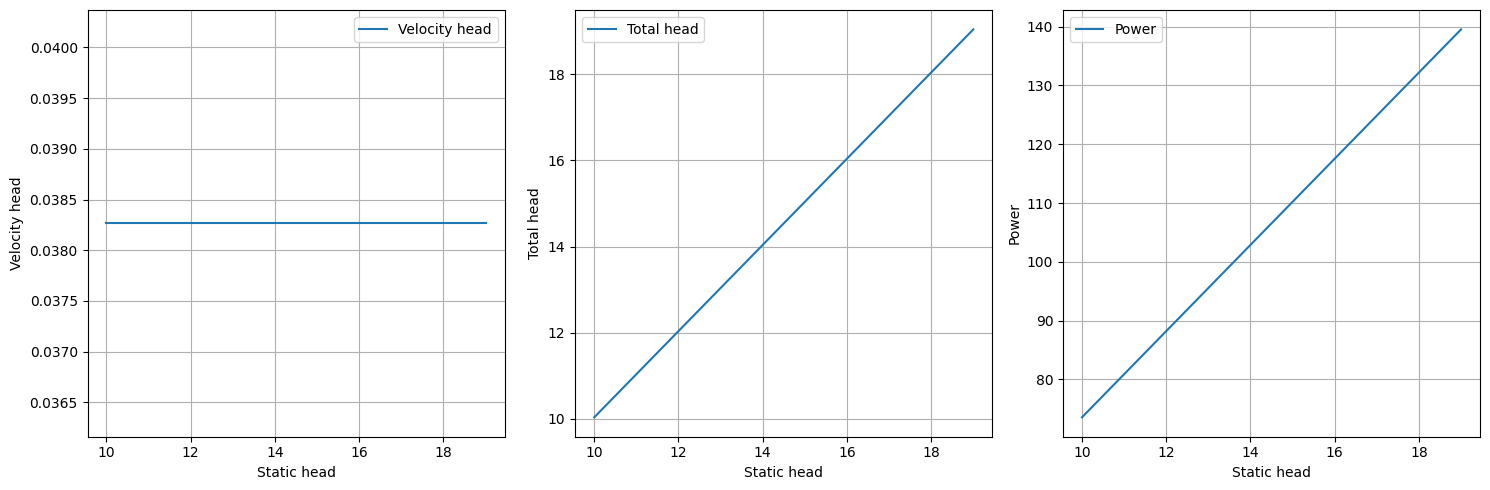

In [9]:
import matplotlib.pyplot as plt

# Extract the data from the results list
Static_head = [row[0] for row in results]
Velocity_head = [row[1] for row in results]
Total_Head = [row[2] for row in results]
Power = [row[3] for row in results]

# Plotting the results
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].plot(Static_head, Velocity_head, label='Velocity head')
axs[0].set_xlabel('Static head')
axs[0].set_ylabel('Velocity head')
axs[0].legend()
axs[0].grid()

axs[1].plot(Static_head, Total_Head, label='Total head')
axs[1].set_xlabel('Static head')
axs[1].set_ylabel('Total head')
axs[1].legend()
axs[1].grid()

axs[2].plot(Static_head, Power, label='Power')
axs[2].set_xlabel('Static head')
axs[2].set_ylabel('Power')
axs[2].legend()
axs[2].grid()

plt.tight_layout()
plt.show()

### Automation of Hydroelectric Turbines for a range of inlet velocity

In [10]:
from tabulate import tabulate

# Set the initial inlet velocity
Inlet_Velocity = float(input("Enter the initial inlet velocity: "))
HT.set_StaticHead(1) # Setting to default of 1 m of static head.

# Set the solver mode to use the default solver
Settings.SolverMode = 0

# Create an empty list to store the results
results = []

# Iterate 10 times, increasing the inlet velocity by 1 m/s each time
for i in range(10):
    # Set the new inlet velocity
    HT.set_InletVelocity(Inlet_Velocity)
    
    # Calculate the flowsheet
    errors = interf.CalculateFlowsheet2(sim)
    
    # Get the results
    Velocity_head = HT.get_VelocityHead()
    Total_Head = HT.get_TotalHead()
    Power = HT.get_GeneratedPower()

    # Append the results to the list
    results.append([Inlet_Velocity, Velocity_head, Total_Head, Power])

    # Increase the inlet velocity by 1 m/s for the next iteration
    Inlet_Velocity += 1.0

# Define the headers for the table
headers = ["Inlet Veloicty", "Velocity head", "Total head", "Power Generated"]

# Print the results in a table format
print(tabulate(results, headers=headers, tablefmt="grid"))


+------------------+-----------------+--------------+-------------------+
|   Inlet Veloicty |   Velocity head |   Total head |   Power Generated |
+==================+=================+==============+===================+
|               10 |         5.08929 |      6.08929 |           44.6241 |
+------------------+-----------------+--------------+-------------------+
|               11 |         6.16071 |      7.16071 |           52.4759 |
+------------------+-----------------+--------------+-------------------+
|               12 |         7.33418 |      8.33418 |           61.0754 |
+------------------+-----------------+--------------+-------------------+
|               13 |         8.60969 |      9.60969 |           70.4227 |
+------------------+-----------------+--------------+-------------------+
|               14 |         9.98724 |     10.9872  |           80.5179 |
+------------------+-----------------+--------------+-------------------+
|               15 |        11.4668  |

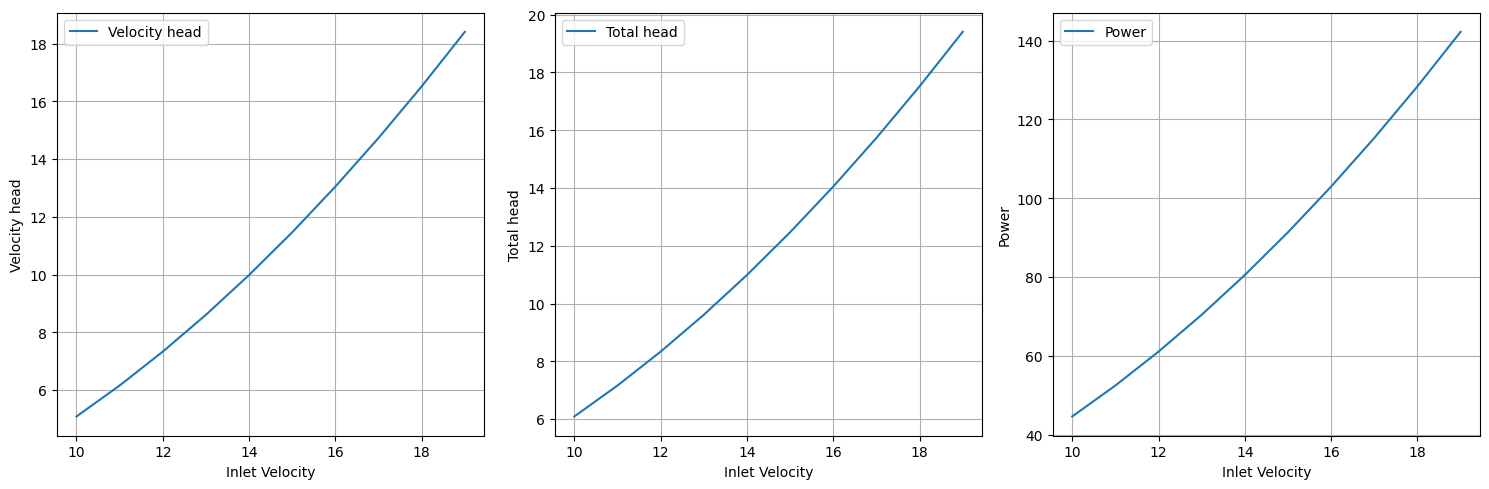

In [11]:
import matplotlib.pyplot as plt

# Extract the data from the results list
Inlet_Velocity = [row[0] for row in results]
Velocity_head = [row[1] for row in results]
Total_Head = [row[2] for row in results]
Power = [row[3] for row in results]

# Plotting the results
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].plot(Inlet_Velocity, Velocity_head, label='Velocity head')
axs[0].set_xlabel('Inlet Velocity')
axs[0].set_ylabel('Velocity head')
axs[0].legend()
axs[0].grid()

axs[1].plot(Inlet_Velocity, Total_Head, label='Total head')
axs[1].set_xlabel('Inlet Velocity')
axs[1].set_ylabel('Total head')
axs[1].legend()
axs[1].grid()

axs[2].plot(Inlet_Velocity, Power, label='Power')
axs[2].set_xlabel('Inlet Velocity')
axs[2].set_ylabel('Power')
axs[2].legend()
axs[2].grid()

plt.tight_layout()
plt.show()

### Saving the file

In [12]:
# saving the modified version of file at same path

fileNameToSave = Path.Combine(Environment.GetFolderPath(Environment.SpecialFolder.Desktop), "/workspace/05 Automation of Hydroelectric Turbines/00 Modified_flowsheet.dwxmz")

interf.SaveFlowsheet(sim, fileNameToSave, True)

#### Disclamer

The exercise done was to understand how automation can be used for Hydroelectric Turbines in DWSim. It does not contains any process data from a live plant under operating conditions but yes the same can be replicated if customer data is available